In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [4]:
df=pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [5]:
df.shape

(7588, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [7]:
###Statistical information
df.describe()


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [8]:
#### Checking for missing values
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [9]:
### Checking for duplicates
df.duplicated().sum()

np.int64(0)

### Therefore there are neither missing values nor duplicates in the given dataset

In [10]:
### Now changing the first column which is labelled as object to datetime type and then considering it as index
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0],dayfirst=True)  


In [11]:
df.set_index(df.columns[0], inplace=True)

In [12]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [15]:
### Renaming the exchane rate column name
df.columns = ["USD_AUD"]
df.head(2)

,USD_AUD
date,
1990-01-01,0.7855
1990-01-02,0.7818


#### 2. Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

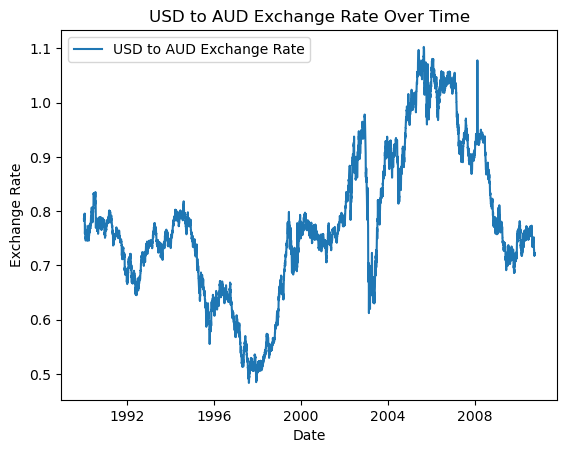

In [19]:
plt.plot(df,label="USD to AUD Exchange Rate")
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

#### 2: Model Building - ARIMA
##### Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
##### Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
##### Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
##### Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

####  Utilizing ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

In [22]:
#Stationarity Test (ADF)
adf_result = adfuller(df["USD_AUD"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -1.664994180738078
p-value: 0.44923273535982894


In [23]:
# If p-value > 0.05 → non-stationary → differencing required

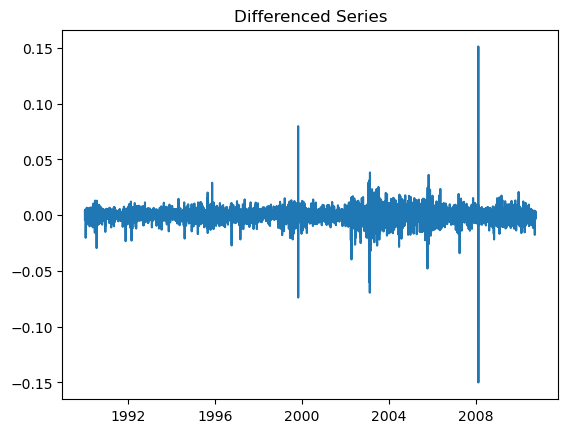

In [24]:
# Differencing
df_diff = df.diff().dropna()
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

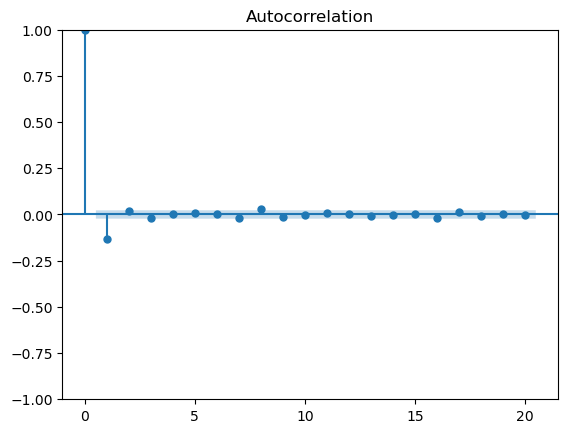

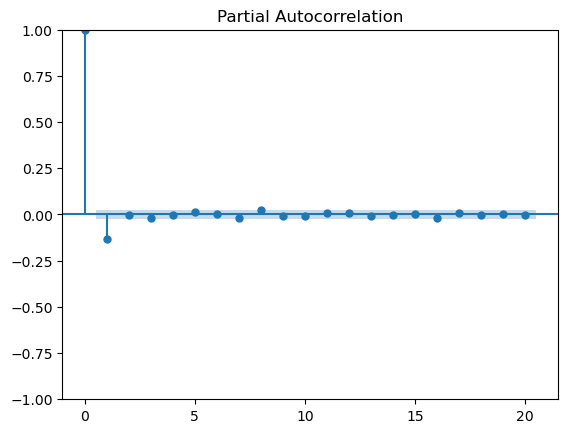

In [25]:
### Next, plotting ACF and PCF
# ACF & PACF
plot_acf(df_diff, lags=20)
plt.show()
plot_pacf(df_diff, lags=20)
plt.show()
# Selected order: (1,1,1)

#### 2. Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [26]:
# Train-Test Split
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
print("Train size:", len(train))
print("Test size :", len(test))


Train size: 6070
Test size : 1518


In [27]:
# ARIMA Model
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Tue, 12 May 2026   AIC                         -45432.092
Time:                        18:42:05   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

#### 3.. Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

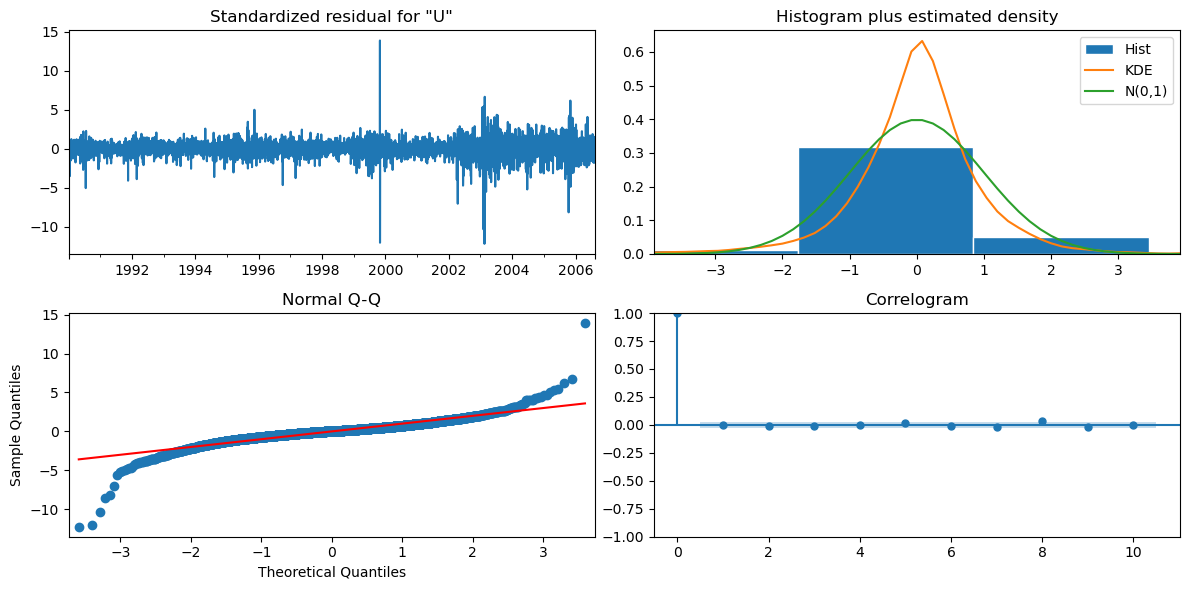

In [28]:
# Plitting the Diagnostic plots
arima_fit.plot_diagnostics(figsize=(12, 6))
plt.tight_layout()
plt.show()

#### 4. Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

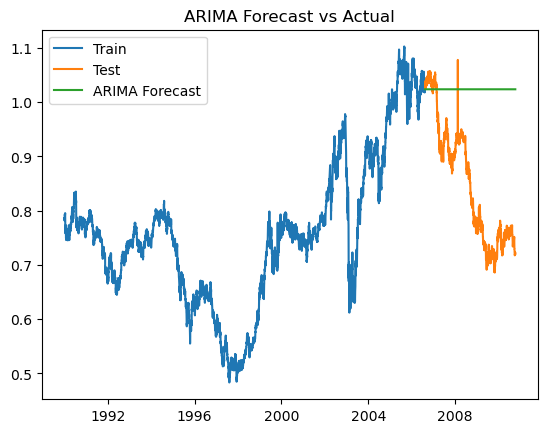

In [35]:
# ARIMA Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

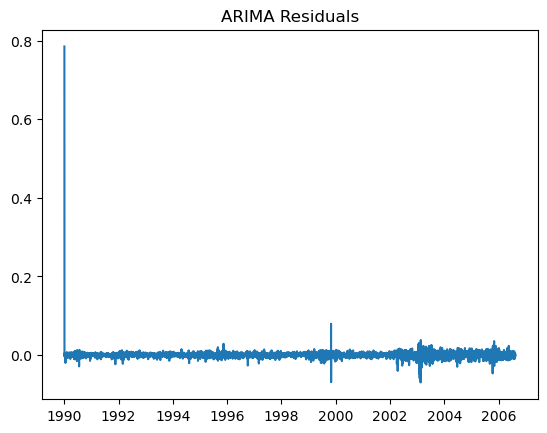

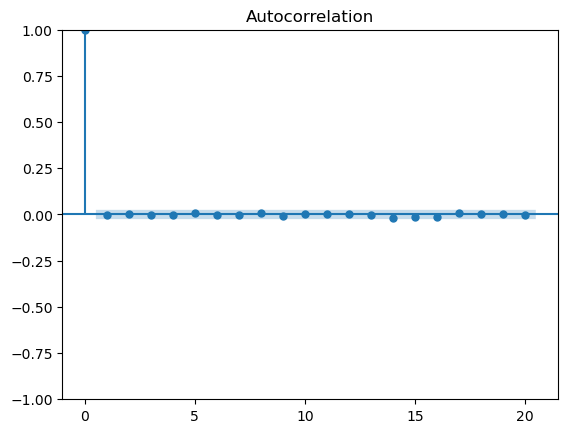

In [36]:
#Residual Diagnostics
residuals = arima_fit.resid
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()
plot_acf(residuals, lags=20)
plt.show()

In [37]:
# Smoothing the exponentials
ets_model = ExponentialSmoothing(train,trend="add",seasonal=None)
ets_fit = ets_model.fit()

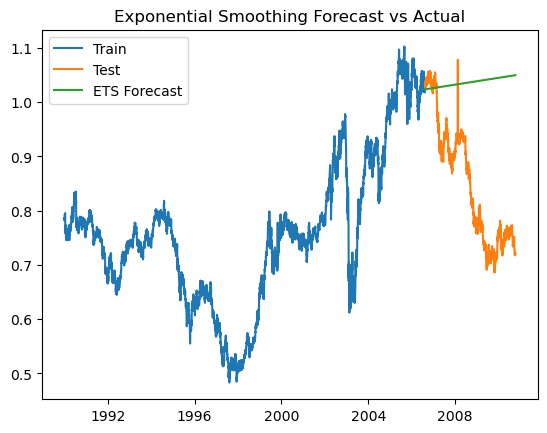

In [39]:
# ETS Forecast
ets_forecast = ets_fit.forecast(len(test))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, ets_forecast, label="ETS Forecast")
plt.title("Exponential Smoothing Forecast vs Actual")
plt.legend()
plt.show()

#### Part 3: Evaluation and Comparison

In [40]:
# Evaluation Metrics
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

In [41]:
### Now evaluating the model based on the values obtained
arima_mae, arima_rmse, arima_mape = evaluate_model(test, arima_forecast)
ets_mae, ets_rmse, ets_mape = evaluate_model(test, ets_forecast)

In [42]:
print("\nARIMA Performance")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

print("\nExponential Smoothing Performance")
print("MAE :", ets_mae)
print("RMSE:", ets_rmse)
print("MAPE:", ets_mape)


ARIMA Performance
MAE : 0.1777097044912133
RMSE: 0.20543669659669261
MAPE: nan

Exponential Smoothing Performance
MAE : 0.19027449606489796
RMSE: 0.22008638668287628
MAPE: nan


In [43]:
# Model Comparison
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [arima_mae, ets_mae],
    "RMSE": [arima_rmse, ets_rmse],
    "MAPE": [arima_mape, ets_mape]
})

print("\nFinal Model Comparison")
print(comparison)


Final Model Comparison
                   Model       MAE      RMSE  MAPE
0                  ARIMA  0.177710  0.205437   NaN
1  Exponential Smoothing  0.190274  0.220086   NaN
